# Predicting car prices with linear regression

We have a dataset of cars. Each car is described by a set of features (make, model, year, engine power, fuel economy, ...) and has a price, stored in the `msrp` column. The goal of this project is to train a linear regression model that can predict the price of a car it has never seen.

In other words, our model will be a car-pricing expert, so you won't need to pay a human to tell you what the car you want to buy or sell is worth. Just kidding: ask real experts too, because this model is far from reliable. And paying humans for their expertise is a nice thing to do anyway. It's up to you. Let's go!

The model is implemented from scratch with NumPy (no scikit-learn), following the car-price project from chapter 2 of Alexey Grigorev's *Machine Learning Bookcamp* / ML Zoomcamp.

**Contents**
1. Preparing the dataset
2. Train, validation and test sets
3. A first model: linear regression on numerical features
4. Adding the age of the car
5. A categorical feature: number of doors
6. We forgot something: cars with 0 doors
7. The fix: drop one door column
8. Do the doors actually help?
9. The make of the car
10. Does the make actually help?
11. Ridge regression
12. The final model: one look at the test set
13. Results and what to try next
14. Just tell me what my car is worth

**In a hurry?** Choose Restart & Run All, then jump to section 14 and put your own car into the last cell.

## Setup

Create a virtual environment in the project folder, activate it, and install the packages used here:

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows
source .venv/bin/activate       # macOS / Linux
pip install numpy pandas matplotlib ipykernel
```

If you get an error about a missing package, install it with `pip install <package>`. For any other error, search for the error message (or ask an AI assistant).

This notebook was written with Python 3.12, NumPy 2, pandas 3 and Matplotlib 3.

In [ ]:
# Every chart in this notebook shares one look: a light background, thin grey gridlines, and a fixed order
# of colors (blue, then orange, then green), so that a color keeps its meaning within a chart.
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#898781'
BACKGROUND, INK = '#fcfcfb', '#0b0b0b'

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'text.color': INK,
    'legend.frameon': False,
    'lines.linewidth': 2,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, GREEN]),
})

## 1. Preparing the dataset

In [ ]:
# Download the dataset from a public source (only if we don't have it yet).
# Python's urllib works the same on Windows, macOS and Linux, unlike !wget or !curl.
from pathlib import Path
from urllib.request import urlretrieve

url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

if not Path('data.csv').exists():
    urlretrieve(url, 'data.csv')

In [ ]:
# Now let's look at the data with pandas.
import numpy as np
import pandas as pd

df = pd.read_csv('data.csv')

# the first 5 rows of the data frame
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
# The table is not quite ready to use yet. The column names are inconsistent: some are capitalized and
# some contain spaces (e.g. 'Engine HP', 'highway MPG'), which makes them awkward to type.
print(df.columns.tolist())

# Let's make them lower case and replace the spaces with underscores.
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']
['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity', 'msrp']


In [ ]:
# The text entries have the same problem ('BMW' vs 'bmw'), so let's lower-case them too.
# .str.lower() only works on text columns, so first we find the columns that contain text.
strings = [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]
print(strings)

for col in strings:
    df[col] = df[col].str.lower()

df.head()

['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1 series m,2011,premium unleaded (required),335.0,6.0,manual,rear wheel drive,2.0,"factory tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1 series,2011,premium unleaded (required),300.0,6.0,manual,rear wheel drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1 series,2011,premium unleaded (required),230.0,6.0,manual,rear wheel drive,2.0,luxury,compact,convertible,28,18,3916,34500


### The target: `msrp`

`msrp` stands for *Manufacturer's Suggested Retail Price*. This is what we want to predict.

The prices are very skewed. Most cars cost a few tens of thousands of dollars, but a few cost hundreds of thousands, up to about 2 million dollars. Those few very expensive cars would dominate the errors of a linear model. So instead of the price itself we predict its logarithm, which squeezes the large values together. We use `np.log1p(x)`, which is log(1 + x) and is safe even for a price of 0. `np.expm1` turns a prediction back into dollars.

In [ ]:
# The mean price is far above the median because of a few very expensive cars.
print(df.msrp.describe().round())

# Instead of overwriting msrp, we add a new column with the log price.
df['msrp_log'] = np.log1p(df.msrp)

df[['msrp', 'msrp_log']].head()

count      11914.0
mean       40595.0
std        60109.0
min         2000.0
25%        21000.0
50%        29995.0
75%        42231.0
max      2065902.0
Name: msrp, dtype: float64


,msrp,msrp_log
0,46135,10.739349
1,40650,10.612779
2,36350,10.500977
3,29450,10.290483
4,34500,10.448744


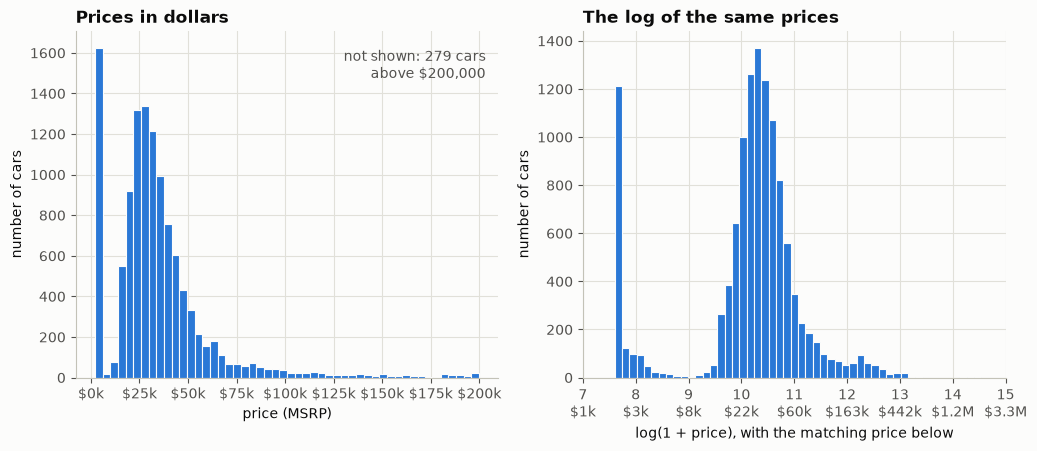

cars priced at exactly $2,000: 1036  (log(1 + 2000) = 7.60)


In [ ]:
def label_log_prices(axis, ticks=range(8, 15)):
    # Put the dollar amount under each tick of a log(1 + price) axis, so the reader can translate.
    def dollars(value):
        return f'${value / 1e6:.1f}M' if value >= 1e6 else f'${value / 1e3:,.0f}k'
    axis.set_ticks(list(ticks))
    axis.set_ticklabels([f'{t}\n{dollars(np.expm1(t))}' for t in ticks])


cap = 200_000
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))

left.hist(df.msrp[df.msrp <= cap], bins=50, color=BLUE, edgecolor=BACKGROUND, linewidth=0.8)
left.set_title('Prices in dollars')
left.set_xlabel('price (MSRP)')
left.set_ylabel('number of cars')
left.xaxis.set_major_formatter(lambda value, _: f'${value / 1e3:,.0f}k')
left.text(0.97, 0.95, f'not shown: {(df.msrp > cap).sum()} cars\nabove ${cap:,}', transform=left.transAxes,
          ha='right', va='top', color='#52514e')

right.hist(df.msrp_log, bins=50, color=BLUE, edgecolor=BACKGROUND, linewidth=0.8)
right.set_title('The log of the same prices')
right.set_xlabel('log(1 + price), with the matching price below')
right.set_ylabel('number of cars')
label_log_prices(right.xaxis, ticks=range(7, 16))
plt.show()

print(f"cars priced at exactly $2,000: {(df.msrp == 2000).sum()}  (log(1 + 2000) = {np.log1p(2000):.2f})")

**Reading the chart.** Both panels count cars (vertical axis) in each price range (horizontal axis). On the left, in dollars, most cars cost between about \$15,000 and \$50,000, and a long, thin tail stretches to the right: 279 cars above \$200,000 don't even fit on the chart. On the right are the same prices after taking the log. The main group becomes a roughly symmetric hill centred near 10.3 (about \$30,000), and the tail shrinks to a short slope. A linear model trained on squared errors copes far better with that symmetric shape.

Both panels also show a tall spike at the far left: 1,036 cars priced at exactly \$2,000 (7.60 on the log scale). All of them are from 1990–2000. \$2,000 is a placeholder in the data, not a real price, and it shows up again in every chart of predictions below.

In [ ]:
# Another issue: some entries are missing (NaN, null). Let's count them in each column.
print(df.isna().sum())

# For this tutorial, we simply fill every missing value with 0. This is a shortcut, not a careful choice,
# and in section 6 we will see that it has consequences.
df = df.fillna(0)

print('missing values left:', df.isna().sum().sum())

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
msrp_log                0
dtype: int64
missing values left: 0


## 2. Train, validation and test sets

We split the cars randomly into three groups:

- **train (60%)**: the model learns its weights from these cars.
- **validation (20%)**: we use these to compare models, for example to decide whether a new feature helps.
- **test (20%)**: kept aside until the very end, to get one honest estimate of how the final model does on cars it has never seen.

If we chose features by looking at the test score, the test cars would no longer be "unseen", and the final score would be too optimistic. So all the comparisons in this notebook use the validation set.

In [ ]:
import random

def dataflow(df: pd.DataFrame, train_ratio: float = 0.6, valid_ratio: float = 0.2, seed: int = 0):
    N = len(df)

    # We shuffle the rows before splitting. But we want the SAME shuffle every time we run this,
    # otherwise each run trains on a different split and we get a different rmse every time
    # (which makes it impossible to tell if a new feature really helped).
    # random.Random(seed) gives us our own generator, so we don't disturb the global random state.
    rng = random.Random(seed)
    random_list = rng.sample(range(N), N)

    len_train = int(train_ratio * N)
    len_valid = int(valid_ratio * N)

    # random_list contains POSITIONS (0, 1, 2, ... N-1), so we select with .iloc, which is
    # position-based. .loc would be label-based: it only works by luck while the index is
    # still 0..N-1, and breaks silently as soon as we drop or filter rows (which we will do later).
    df_train = df.iloc[random_list[:len_train]]
    df_valid = df.iloc[random_list[len_train:len_train + len_valid]]
    df_test = df.iloc[random_list[len_train + len_valid:]]

    # train + validation together: for training the final model at the very end
    df_train_valid = pd.concat([df_train, df_valid])

    assert len(df_train) + len(df_valid) + len(df_test) == N

    return {'df_train': df_train, 'df_valid': df_valid, 'df_test': df_test, 'df_train_valid': df_train_valid}


# let's create the split
dataset = dataflow(df)

df_train = dataset['df_train']
df_valid = dataset['df_valid']
df_test = dataset['df_test']

len(df_train), len(df_valid), len(df_test)

(7148, 2382, 2384)

## 3. A first model: linear regression on numerical features

The input of a linear regression model is a matrix: each row describes one car, and each column is one feature. Which features should we use? More features may give better predictions, but let's start simple with four numerical ones: engine power, highway and city fuel economy (mpg), and popularity. We will add other kinds of features later.

In [ ]:
base = ['engine_hp', 'highway_mpg', 'city_mpg', 'popularity']

X = df[base].values
X

array([[ 335.,   26.,   19., 3916.],
       [ 300.,   28.,   19., 3916.],
       [ 300.,   28.,   20., 3916.],
       ...,
       [ 300.,   23.,   16.,  204.],
       [ 300.,   23.,   16.,  204.],
       [ 221.,   26.,   17.,   61.]], shape=(11914, 4))

In [ ]:
# Let's put this into a function.
def input_matrix(df: pd.DataFrame):
    base_features = ['engine_hp', 'highway_mpg', 'city_mpg', 'popularity']
    X = df[base_features].values

    # We add a column of 1's in front. Its weight will be the bias term of the linear regression model.
    X = np.column_stack([np.ones(X.shape[0]), X])

    return X


X_train = input_matrix(df_train)
X_train

array([[1.000e+00, 3.100e+02, 3.100e+01, 2.100e+01, 1.550e+02],
       [1.000e+00, 3.030e+02, 2.500e+01, 1.700e+01, 6.100e+01],
       [1.000e+00, 3.150e+02, 3.000e+01, 2.100e+01, 3.916e+03],
       ...,
       [1.000e+00, 2.830e+02, 2.400e+01, 1.600e+01, 1.851e+03],
       [1.000e+00, 2.000e+02, 1.800e+01, 1.400e+01, 1.385e+03],
       [1.000e+00, 2.000e+02, 2.100e+01, 1.600e+01, 5.657e+03]],
      shape=(7148, 5))

### Training: the normal equation

Linear regression predicts a car's (log) price as a weighted sum of its features:

```
prediction = w0 + w1 * engine_hp + w2 * highway_mpg + w3 * city_mpg + w4 * popularity
```

The weights $w$ that make the squared errors on the training cars as small as possible are given by the *normal equation*:

$$w = (X^T X)^{-1} X^T y$$

where $X$ is the input matrix (with the column of 1's) and $y$ holds the training prices. We implement it directly with NumPy.

In [ ]:
# The following function gives us the vector w: how much weight to put on each feature to predict the price
# of a car. Note that w[0] is the bias term: our starting guess for the (log) price of a typical car, before
# we use any information about its features.

def linear_regression_training(X: np.ndarray, y: np.ndarray):  # X: input matrix for training, y: prices
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    # one weight per column of X
    assert w.shape[0] == X.shape[1]

    return w  # note: this is a vector


y_train = df_train.msrp_log.values  # prices of the training cars, on the log scale
w = linear_regression_training(X_train, y_train)
w

array([ 7.17907836e+00,  8.06725008e-03,  2.20253340e-02,  1.92695701e-02,
       -2.26188856e-05])

In [ ]:
# Root mean squared error: roughly, the typical size of a prediction error (here in log-price units).
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [ ]:
# Train on the training set, then predict and measure the error on another set of cars.
def model_prediction(X_train, y_train, X_eval, y_eval):
    w = linear_regression_training(X_train, y_train)
    predictions = X_eval @ w
    error = rmse(y_eval, predictions)
    return predictions, error


X_train = input_matrix(df_train)
y_train = df_train.msrp_log.values
X_valid = input_matrix(df_valid)
y_valid = df_valid.msrp_log.values

y_pred, error = model_prediction(X_train, y_train, X_valid, y_valid)
error

np.float64(0.7734149758173117)

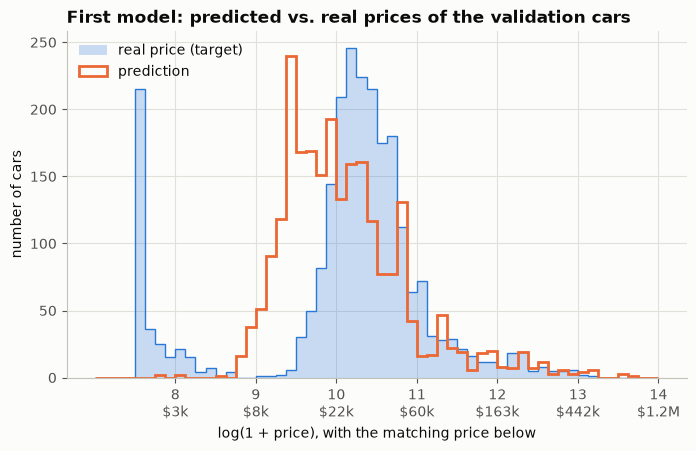

validation cars with a real price under $5,000: 338, predicted under $5,000: 4


In [ ]:
def plot_predictions(ax, real, predicted, title):
    # The real log prices as a filled shape, the predictions as an orange outline on the same bins.
    bins = np.linspace(7, 14, 57)
    ax.hist(real, bins=bins, histtype='stepfilled', color=BLUE, alpha=0.25, label='real price (target)')
    ax.hist(real, bins=bins, histtype='step', color=BLUE, linewidth=1)
    ax.hist(predicted, bins=bins, histtype='step', color=ORANGE, linewidth=2, label='prediction')
    ax.set_title(title)
    ax.set_xlabel('log(1 + price), with the matching price below')
    ax.set_ylabel('number of cars')
    label_log_prices(ax.xaxis)
    ax.legend(loc='upper left')


fig, ax = plt.subplots()
plot_predictions(ax, y_valid, y_pred, 'First model: predicted vs. real prices of the validation cars')
plt.show()

under_5k = np.log1p(5000)
print(f'validation cars with a real price under $5,000: {(y_valid < under_5k).sum()}, predicted under $5,000: {(y_pred < under_5k).sum()}')

**Reading the chart.** The horizontal axis is the log price, with the matching dollar amount under each tick, and the vertical axis counts validation cars. The blue shape shows the real prices and the orange outline the model's predictions. A perfect model would draw the orange outline exactly on top of the blue shape.

This one doesn't. The predictions pile up around 9.5 (about \$13,000), where there are hardly any real prices, and they miss the spike of cheap cars on the far left entirely: 338 validation cars really cost under \$5,000, but the model predicts under \$5,000 for only 4 of them. With nothing but engine power, fuel economy and popularity to go on, it can't tell a 1993 car from a 2017 one, so it predicts something in between for both.

In [ ]:
# A user-friendly prediction: give the features of a car, get its price in dollars.
w = linear_regression_training(X_train, y_train)

def predict_price(engine_hp, highway_mpg, city_mpg, popularity):
    x = np.array([1, engine_hp, highway_mpg, city_mpg, popularity])  # the 1 is for the bias
    log_price = x @ w
    return np.expm1(log_price)  # from the log scale back to dollars


predict_price(engine_hp=300, highway_mpg=24, city_mpg=21, popularity=40)

np.float64(37481.05710530743)

## 4. Adding the age of the car

So far we have used four features, but the table has many more columns. Are they useless? Absolutely not. For example, the year a car was made clearly affects its price, so our model should see it too.

In [ ]:
# The raw year (like 2011) is less useful than the age of the car. The newest cars in the data are from 2017,
# so we measure the age relative to 2017 rather than today's date: the newest cars have age 0.
current_year = df.year.max()
current_year

np.int64(2017)

In [ ]:
# We add a new column instead of overwriting 'year', so the original data is preserved.
df['car_age'] = current_year - df.year

df[['year', 'car_age']].head()

,year,car_age
0,2011,6
1,2011,6
2,2011,6
3,2011,6
4,2011,6


In [ ]:
# A more flexible input_matrix: the base features plus any extra features we pass in.
# The defaults are tuples, not lists. A list used as a default value is created once, when the
# `def` runs, and is then shared by every call; if anything ever modified it, the change would
# leak into all later calls. A tuple cannot be modified, so the problem cannot arise.
def input_matrix(df: pd.DataFrame,
                 base_features=('engine_hp', 'highway_mpg', 'city_mpg', 'popularity'),
                 new_features=()):
    features = list(base_features) + list(new_features)
    X = df[features].values

    # the column of 1's for the bias term
    X = np.column_stack([np.ones(X.shape[0]), X])

    return X


# df has a new column now, so we split it again. The seed is fixed, so we get exactly the same split as before.
dataset = dataflow(df)
df_train = dataset['df_train']
df_valid = dataset['df_valid']
df_test = dataset['df_test']

X_train = input_matrix(df_train, new_features=['car_age'])
X_train

array([[1.000e+00, 3.100e+02, 3.100e+01, 2.100e+01, 1.550e+02, 0.000e+00],
       [1.000e+00, 3.030e+02, 2.500e+01, 1.700e+01, 6.100e+01, 0.000e+00],
       [1.000e+00, 3.150e+02, 3.000e+01, 2.100e+01, 3.916e+03, 0.000e+00],
       ...,
       [1.000e+00, 2.830e+02, 2.400e+01, 1.600e+01, 1.851e+03, 2.000e+00],
       [1.000e+00, 2.000e+02, 1.800e+01, 1.400e+01, 1.385e+03, 2.000e+01],
       [1.000e+00, 2.000e+02, 2.100e+01, 1.600e+01, 5.657e+03, 1.500e+01]],
      shape=(7148, 6))

In [ ]:
# Let's train the model with the new feature and check the validation error.
X_train = input_matrix(df_train, new_features=['car_age'])
X_valid = input_matrix(df_valid, new_features=['car_age'])

y_train = df_train.msrp_log.values
y_valid = df_valid.msrp_log.values

predictions, error = model_prediction(X_train, y_train, X_valid, y_valid)
error

np.float64(0.530107142763996)

The validation RMSE drops from 0.773 to 0.530. The age of a car matters a lot.

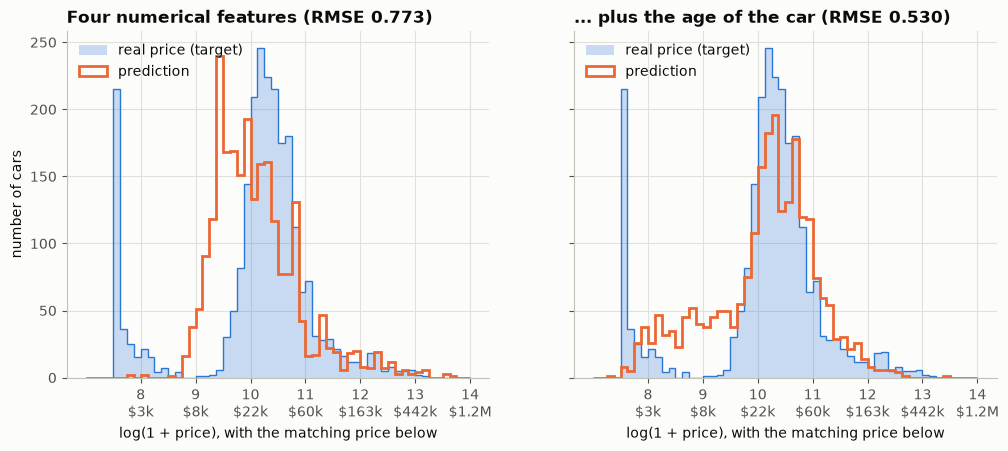

predicted under $5,000: 4 cars by the first model, 219 with the age (real: 338)


In [ ]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
plot_predictions(left, y_valid, y_pred, 'Four numerical features (RMSE 0.773)')
plot_predictions(right, y_valid, predictions, '... plus the age of the car (RMSE 0.530)')
right.set_ylabel('')
plt.show()

print(f'predicted under $5,000: {(y_pred < under_5k).sum()} cars by the first model, '
      f'{(predictions < under_5k).sum()} with the age (real: {(y_valid < under_5k).sum()})')

**Reading the chart.** The left panel repeats the first model; the right panel adds `car_age`. With the age, the orange outline moves onto the blue hill in the middle, and a new group of predictions appears between 7.6 and 9.5 (about \$2,000 to \$13,000): the model has learned that old cars are cheap. It now predicts under \$5,000 for 219 cars instead of 4 (the real number is 338).

It still can't reproduce the spike itself. The \$2,000 cars are old, but so are many cars with real prices, and nothing in the features says "this price is a placeholder". So the model spreads its guesses for them across the whole low range.

## 5. A categorical feature: number of doors

There are more features that an expert would use. Let's consider `number_of_doors`, which clearly has some effect on the price.

We could add it to the base features as a plain number. But then the model would treat 3 doors as exactly halfway between 2 and 4, and every extra door would have to change the price by the same amount. Here the numbers are really *labels*: we could just as well have called them A, B and C. So it is better to treat `number_of_doors` as a **categorical** feature.

For a categorical feature, we add one new column per category, containing 1 if the car belongs to that category and 0 otherwise. This is called **one-hot encoding**.

In [ ]:
# How many cars have each door count?
print(df.number_of_doors.value_counts())

# The 0's are not real door counts: they are the missing values we filled with 0 earlier,
# so we don't create a column for them.
door_counts = sorted(int(n) for n in df.number_of_doors.unique() if n != 0)

for num in door_counts:
    df[f'has_{num}_doors'] = (df.number_of_doors == num).astype(int)

df[['number_of_doors', 'has_2_doors', 'has_3_doors', 'has_4_doors']].head(20)

number_of_doors
4.0    8353
2.0    3160
3.0     395
0.0       6
Name: count, dtype: int64


,number_of_doors,has_2_doors,has_3_doors,has_4_doors
0,2.0,1,0,0
1,2.0,1,0,0
2,2.0,1,0,0
3,2.0,1,0,0
4,2.0,1,0,0
5,2.0,1,0,0
6,2.0,1,0,0
7,2.0,1,0,0
8,2.0,1,0,0
9,2.0,1,0,0


In [ ]:
# Let's train with the three door columns added. We split again so the new columns are included (same seed).
dataset = dataflow(df)
df_train = dataset['df_train']
df_valid = dataset['df_valid']
df_test = dataset['df_test']

features = ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors']
X_train = input_matrix(df_train, new_features=features)
X_valid = input_matrix(df_valid, new_features=features)

y_train = df_train.msrp_log.values
y_valid = df_valid.msrp_log.values

predictions, error = model_prediction(X_train, y_train, X_valid, y_valid)
error

np.float64(0.5279430277592007)

Unlike the age, the door columns barely change the validation RMSE (0.530 → 0.528). We will check more carefully in section 8 whether they help at all. But first, there is something we forgot.

In [ ]:
# Let's put all these repetitive steps into one function: split the data, build the input matrices,
# train on the training set, and measure the rmse on the validation set.
# It also returns the weights w, so that we can look at them.
def model_prediction_full(df: pd.DataFrame,
                          base_features=('engine_hp', 'highway_mpg', 'city_mpg', 'popularity'),
                          new_features=(), seed: int = 0):
    dataset = dataflow(df, seed=seed)
    df_train = dataset['df_train']
    df_valid = dataset['df_valid']

    X_train = input_matrix(df_train, base_features, new_features=new_features)
    X_valid = input_matrix(df_valid, base_features, new_features=new_features)
    y_train = df_train.msrp_log.values
    y_valid = df_valid.msrp_log.values

    w = linear_regression_training(X_train, y_train)
    predictions = X_valid @ w
    error = rmse(y_valid, predictions)

    return predictions, error, w


# the same model as in the cell above, so we get the same rmse
predictions, error, w = model_prediction_full(df, new_features=['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors'])
error

np.float64(0.5279430277592007)

## 6. We forgot something: cars with 0 doors

Look at the door counts again: 6 cars have `number_of_doors == 0`. No car really has zero doors. These are the cars whose door count was **missing**, and our `fillna(0)` turned it into a 0. Let's look at them.

In [ ]:
df[df.number_of_doors == 0][['make', 'model', 'year', 'number_of_doors', 'msrp']]

,make,model,year,number_of_doors,msrp
4666,ferrari,ff,2013,0.0,295000
6930,tesla,model s,2016,0.0,79500
6931,tesla,model s,2016,0.0,66000
6932,tesla,model s,2016,0.0,134500
6933,tesla,model s,2016,0.0,74500
6934,tesla,model s,2016,0.0,71000


In [ ]:
# We don't know their real door count, and they are only 6 out of 11,914 cars, so let's remove them.
indexes = df[df.number_of_doors == 0].index
df_corrected = df.drop(indexes)

print(len(df), len(df_corrected))

11914 11908


In [ ]:
# The same model as before, on the corrected data:
predictions, error, w = model_prediction_full(df_corrected, new_features=['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors'])
error

np.float64(16.535404261052197)

In [ ]:
# The error exploded! Removing 6 cars out of almost 12,000 made it much worse. Something bad has happened.
# Let's compare a few real prices with the predictions, turned back into dollars:
df_valid_corrected = dataflow(df_corrected)['df_valid']

comparison = pd.DataFrame({
    'real price': df_valid_corrected.msrp.values[:6],
    'predicted price': np.expm1(predictions[:6]),
})
comparison.map(lambda price: f'${price:,.0f}')

,real price,predicted price
0,"$58,100",$0
1,"$2,925",$27
2,"$34,495","$719,334,217"
3,"$23,200",$22
4,"$25,065","$69,427"
5,"$34,675","$113,580,141,384"


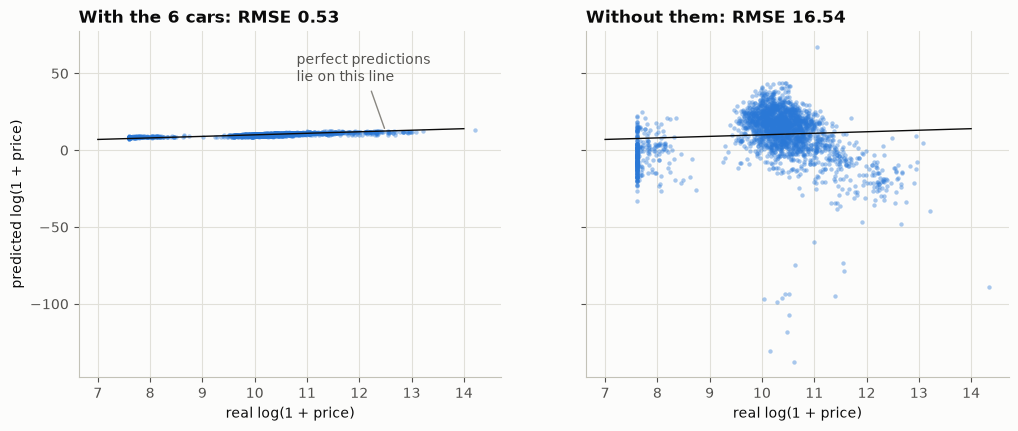

without the 6 cars, the predictions run from -137.7 to 67.3


In [ ]:
# The same model (car_age + 3 door columns) before and after removing the 6 cars: each dot is one validation car.
with_6, error_with_6, _ = model_prediction_full(df, new_features=['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors'])
panels = [(df, with_6, error_with_6, 'With the 6 cars'), (df_corrected, predictions, error, 'Without them')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for ax, (data, predicted, rmse_value, title) in zip(axes, panels):
    real = dataflow(data)['df_valid'].msrp_log.values
    ax.scatter(real, predicted, s=10, color=BLUE, alpha=0.4, linewidths=0)
    ax.plot([7, 14], [7, 14], color=INK, linewidth=1)
    ax.set_title(f'{title}: RMSE {rmse_value:.2f}')
    ax.set_xlabel('real log(1 + price)')
axes[0].set_ylabel('predicted log(1 + price)')
axes[0].annotate('perfect predictions\nlie on this line', xy=(12.5, 12.5), xytext=(10.8, 45),
                 arrowprops=dict(arrowstyle='-', color=GREY), color='#52514e')
plt.show()

print(f'without the 6 cars, the predictions run from {predictions.min():.1f} to {predictions.max():.1f}')

**Reading the chart.** Each dot is one validation car, with its real log price on the horizontal axis and its predicted log price on the vertical axis. Dots on the black diagonal line are perfect predictions. Both panels use the same axes.

With the 6 cars (left), the dots hug the diagonal so closely that at this scale they look like a thick line. Without them (right), the same model predicts log prices from −137.7 to 67.3. A log price of 67 means a car costing about $10^{29}$ dollars. The vertical stripe on the left of the right panel is the \$2,000 cars again (7.6 on the horizontal axis), with predictions scattered over tens of log units. Removing 6 cars out of almost 12,000 should never do this; the next part explains why it did.

### What happened? The dummy variable trap

The problem comes from putting the column of 1's (the bias) and **all three** door columns into the model together. Every car has exactly one door column equal to 1, so for every car:

`has_2_doors + has_3_doors + has_4_doors = 1`, which is exactly the bias column.

Here is a tiny example with four real cars from the data (prices in dollars, other features left out):

| car | bias | has_2 | has_3 | has_4 | price |
|---|---|---|---|---|---|
| Ford Mustang | 1 | 1 | 0 | 0 | 25,645 |
| Ford Transit | 1 | 0 | 1 | 0 | 34,515 |
| Honda Civic | 1 | 0 | 0 | 1 | 19,700 |
| Toyota Camry | 1 | 0 | 0 | 1 | 23,070 |

Each prediction is *bias weight + that car's door weight*. So these two very different sets of weights make exactly the same predictions for every car:

| | bias | has_2 | has_3 | has_4 |
|---|---|---|---|---|
| weights A | 21,385 | 4,260 | 13,130 | 0 |
| weights B | 100,000 | −74,355 | −65,485 | −78,615 |

For example, for the Mustang: 21,385 + 4,260 = 100,000 − 74,355 = 25,645. (Neither set predicts the Civic and the Camry exactly: their rows are identical, so the best any model can do is predict their average, 21,385, for both.)

We can add any number to the bias and subtract the same number from all three door weights without changing a single prediction. Let's call this the *slide*. So there are **infinitely many best answers**, and the door weights mean nothing on their own. In matrix terms, $X^T X$ has no inverse. `np.linalg.inv` does not even raise an error: because of rounding errors, it ends up dividing by a tiny leftover number instead of by 0, and it returns meaningless weights.

**So why did it work before?** Because of the 6 cars we just removed. Their door columns were all 0, so their prediction contains the bias but no door weight. They were the only cars that "notice" the slide, and so, by accident, they pinned it down. Without them, nothing does.

In [ ]:
# Let's check this on the real data: count the cars whose bias column is NOT equal to the sum of their door columns.
features = ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors']
X = input_matrix(df, new_features=features)
X_corrected = input_matrix(df_corrected, new_features=features)

print('df:          ', (X[:, 0] != X[:, -3:].sum(axis=1)).sum(), 'of', len(X), 'cars')
print('df_corrected:', (X_corrected[:, 0] != X_corrected[:, -3:].sum(axis=1)).sum(), 'of', len(X_corrected), 'cars')

df:           6 of 11914 cars
df_corrected: 0 of 11908 cars


In [ ]:
# np.linalg.cond (the condition number) measures how close a matrix is to having no inverse:
# near 1 means healthy, and bigger means worse. As a rule of thumb, NumPy keeps about 16 significant
# digits, and a condition number of about 10^k can cost about k of them.
print(f"df,           3 door columns: {np.linalg.cond(X.T @ X):.1e}")
print(f"df_corrected, 3 door columns: {np.linalg.cond(X_corrected.T @ X_corrected):.1e}")

# The first matrix can lose about 10 of its ~16 digits: fragile, but the result is still usable.
# The second one would lose more than 16, so nothing reliable is left. That is why the rmse exploded.

df,           3 door columns: 3.8e+10
df_corrected, 3 door columns: 1.6e+20


## 7. The fix: drop one door column

If a car is neither 2-door nor 3-door, it must be 4-door. So `has_4_doors` tells the model nothing that the bias and the other two columns don't already tell it. We drop it.

4-door cars become the **reference**: the bias describes a 4-door car, and the `has_2_doors` and `has_3_doors` weights say how 2- and 3-door cars differ from a 4-door car with the same other features. In general, a categorical feature with k categories gets k − 1 columns. It is common to drop the most frequent category, which here is 4 doors (8,353 cars).

In [ ]:
p1, e1, w1 = model_prediction_full(df_corrected, new_features=['car_age', 'has_2_doors', 'has_3_doors'])
print('rmse:', e1)

X_fixed = input_matrix(df_corrected, new_features=['car_age', 'has_2_doors', 'has_3_doors'])
print(f"condition number: {np.linalg.cond(X_fixed.T @ X_fixed):.1e}")

# Much healthier than 1.6e+20. It is still far from 1, mostly because the columns have very different scales
# (popularity goes up to the thousands, the door columns are 0 or 1). That part is harmless here: with every
# column rescaled to the same scale, the condition number would be about 20.

rmse: 0.5143033573362272
condition number: 2.2e+08


In [ ]:
# Does it matter which door column we drop? Let's drop has_2_doors instead, so 2-door cars become the reference.
p2, e2, w2 = model_prediction_full(df_corrected, new_features=['car_age', 'has_3_doors', 'has_4_doors'])
print('rmse:', e2)

# The predictions are the same (up to rounding errors) ...
print('largest difference between the two sets of predictions:', np.abs(p1 - p2).max())

rmse: 0.5143033573362281
largest difference between the two sets of predictions: 1.9539925233402755e-13


In [ ]:
# ... but the door weights are not. Let's write both models as (bias, has_2, has_3, has_4), with 0 for the
# dropped column. (The other weights, for engine_hp, mpg, etc., are identical in the two models.)
w1_full = np.array([w1[0], w1[-2], w1[-1], 0])  # 4-door is the reference
w2_full = np.array([w2[0], 0, w2[-2], w2[-1]])  # 2-door is the reference

print('4-door reference:', w1_full.round(4))
print('2-door reference:', w2_full.round(4))
print('difference:      ', (w2_full - w1_full).round(4))

# The bias goes up by 0.0331 and all three door weights go down by 0.0331: that is the slide from the dummy
# variable trap. The two models just split each door type's price differently between the bias and the door
# weight. The total, bias + door weight, is the same in both:
for name, i in [('2-door', 1), ('3-door', 2), ('4-door', 3)]:
    print(f"{name}: {w1_full[0] + w1_full[i]:.5f} vs {w2_full[0] + w2_full[i]:.5f}")

4-door reference: [ 9.6249  0.0331 -0.1516  0.    ]
2-door reference: [ 9.6581  0.     -0.1847 -0.0331]
difference:       [ 0.0331 -0.0331 -0.0331 -0.0331]
2-door: 9.65805 vs 9.65805
3-door: 9.47332 vs 9.47332
4-door: 9.62495 vs 9.62495


In [ ]:
# Now the door weights have a clear meaning. The target is log(price), so a weight of 0.03 means a price
# about 3% higher; np.expm1 gives the exact percentage.
print(f"Compared with a 4-door car with the same horsepower, mpg, popularity and age, "
      f"a 2-door car is {np.expm1(w1[-2]):.1%} more expensive.")
print(f"Compared with a 4-door car with the same horsepower, mpg, popularity and age, "
      f"a 3-door car is {-np.expm1(w1[-1]):.1%} cheaper.")

Compared with a 4-door car with the same horsepower, mpg, popularity and age, a 2-door car is 3.4% more expensive.
Compared with a 4-door car with the same horsepower, mpg, popularity and age, a 3-door car is 14.1% cheaper.


## 8. Do the doors actually help?

With the age alone, the validation RMSE on `df_corrected` is 0.5146; with the two door columns it is 0.5143. (These numbers differ from section 4 because removing 6 cars changes the random split.) That's a very small change. Is it a real improvement, or just luck in which cars landed in the validation set? To find out, we repeat the comparison with 40 different random splits (seeds).

In [ ]:
errors_age = []    # validation rmse with car_age only
errors_doors = []  # validation rmse with car_age + the two door columns

for seed in range(40):
    _, e_age, _ = model_prediction_full(df_corrected, new_features=['car_age'], seed=seed)
    _, e_doors, _ = model_prediction_full(df_corrected, new_features=['car_age', 'has_2_doors', 'has_3_doors'], seed=seed)
    errors_age.append(e_age)
    errors_doors.append(e_doors)

errors_age = np.array(errors_age)
errors_doors = np.array(errors_doors)
improvement = errors_age - errors_doors  # positive = the doors helped

print(f"average improvement from the doors: {improvement.mean():+.5f}")
print(f"the doors helped on {(improvement > 0).sum()} of 40 seeds")
print(f"the improvement ranges from {improvement.min():+.4f} to {improvement.max():+.4f}")
print(f"for comparison, the rmse itself changes from seed to seed by about {errors_age.std():.4f} (standard deviation)")

average improvement from the doors: -0.00001
the doors helped on 31 of 40 seeds
the improvement ranges from -0.0077 to +0.0022
for comparison, the rmse itself changes from seed to seed by about 0.0102 (standard deviation)


The doors help on most seeds (31 of 40), but only by a tiny amount, and on the seeds where they hurt, they hurt by more (up to 0.0077). On average the improvement is −0.00001, which is essentially zero. For comparison, simply picking a different random split moves the RMSE by about 0.01, far more than anything the doors do.

So the honest conclusion is that **the number of doors does not improve the model**, at least not on top of the features we already have. That is a useful result too: not every feature that sounds relevant actually helps, and the only way to know is to measure it.

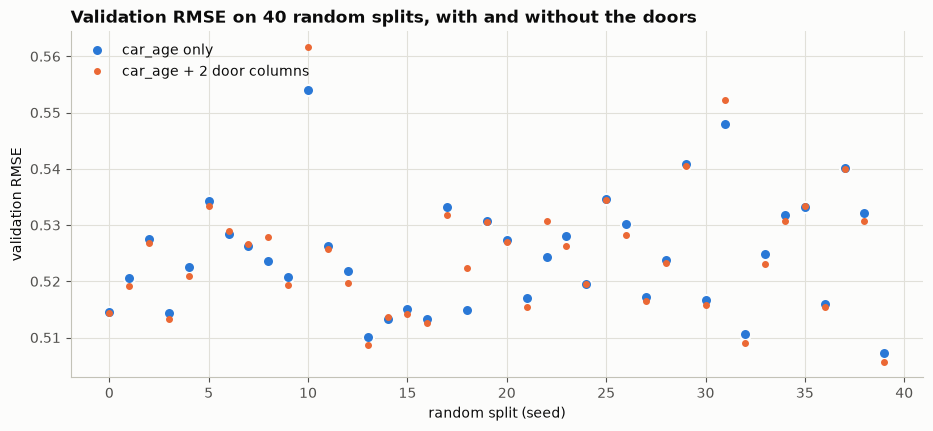

the three splits where the doors hurt most: [10 18 22]


In [ ]:
seeds = np.arange(40)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(seeds, errors_age, 'o', color=BLUE, markersize=8, markeredgecolor=BACKGROUND, markeredgewidth=1.5,
        label='car_age only')
ax.plot(seeds, errors_doors, 'o', color=ORANGE, markersize=4, label='car_age + 2 door columns')
ax.set_title('Validation RMSE on 40 random splits, with and without the doors')
ax.set_xlabel('random split (seed)')
ax.set_ylabel('validation RMSE')
ax.legend(loc='upper left')
plt.show()

print('the three splits where the doors hurt most:', np.argsort(improvement)[:3])

**Reading the chart.** Each of the 40 positions on the horizontal axis is a different random split of the cars into training, validation and test sets, and the vertical axis is the validation RMSE on that split (lower is better). The blue dots are the model with `car_age` only; the small orange dots are the same model with the two door columns added.

On almost every split the orange dot sits right on top of the blue one: the doors change almost nothing. The blue dots, meanwhile, jump between about 0.505 and 0.555 from one split to the next, so which cars happen to land in the validation set matters far more than the doors. Where the two dots do separate (splits 10, 18 and 22 most of all), the orange one is higher: there, the doors made the model worse.

## 9. The make of the car

A Ferrari and a Fiat with the same horsepower, fuel economy and age are not the same price. The `make` column holds exactly that information, and it is the strongest feature we have not used yet.

`make` is categorical, like the number of doors, so we one-hot encode it the same way: one column per make, then drop one of them as the reference. There are 48 makes, so that is 47 new columns. That is a lot of columns, but nothing in the normal equation objects to a wide matrix.

(We could instead keep only the most common makes -- say the top 5 -- and let the other 43 share the reference category. That is a perfectly valid model, just a coarser one: it could tell a Chevrolet from a Ford, but not a Ferrari from a Fiat. We use all 48 here.)

One practical detail first. `df_corrected` was created back in section 6 as a **copy** of `df`, so columns we add to `df` now will not appear in it. We add the make columns to `df` and then rebuild `df_corrected` from it.

In [ ]:
# One column per make. We sort the makes so that the column order depends on the data, not on the
# order the rows happen to be stored in.
all_makes = sorted(df.make.unique())

for make in all_makes:
    df[f'make_is_{make}'] = (df.make == make).astype(int)

# df_corrected was a copy taken in section 6, so it does not have the new columns yet. Rebuild it.
df_corrected = df.drop(df[df.number_of_doors == 0].index)

# As in section 7, we drop the most frequent category and make it the reference.
reference_make = df_corrected.make.value_counts().index[0]
make_columns = [f'make_is_{make}' for make in all_makes if make != reference_make]

print('makes:', len(all_makes))
print('reference:', reference_make, f'({(df_corrected.make == reference_make).sum()} cars)')
print('columns used:', len(make_columns))

makes: 48
reference: chevrolet (1123 cars)
columns used: 47


Let's start the way we started with the doors: put **all** 48 make columns in and see what happens.

In [ ]:
all_make_columns = [f'make_is_{make}' for make in all_makes]
door_columns = ['has_2_doors', 'has_3_doors']

predictions, error, w = model_prediction_full(
    df_corrected, new_features=['car_age'] + door_columns + all_make_columns)
print('rmse:', error)

X = input_matrix(df_corrected, new_features=['car_age'] + door_columns + all_make_columns)
print(f"condition number: {np.linalg.cond(X.T @ X):.1e}")

rmse: 111.29613378343505
condition number: 1.8e+25


The same explosion as in section 6, for the same reason: every car has exactly one make, so the 48 make columns always add up to the bias column. We already know the fix -- drop one column and let it be the reference.

In [ ]:
# 47 columns instead of 48. chevrolet is now the reference.
features = ['car_age'] + door_columns + make_columns

predictions, error, w = model_prediction_full(df_corrected, new_features=features)
print('rmse:', error)

X = input_matrix(df_corrected, new_features=features)
print(f"condition number: {np.linalg.cond(X.T @ X):.1e}")

rmse: 95.2454557555973
condition number: 2.4e+20


### Still broken: a second trap

The fix that worked for the doors did not work here. The RMSE is still hopeless and the condition number is still about $10^{20}$, so $X^T X$ still has no usable inverse. Something *else* in the matrix is redundant.

It is `popularity`, one of the four base features we have been using since section 3.

`popularity` is not a property of a car. It is a property of a **make**: each of the 48 makes has exactly one popularity value, and every BMW row says 3916. So once the model has a column for every make, it can rebuild the whole `popularity` column out of them:

```
popularity = 1385 * (bias column) + (that make's value - 1385) * (that make's column)
```

where 1385 is chevrolet's value, our reference. That is an exact recipe, just like `has_2 + has_3 + has_4 = bias` was. Let's check it against the real column.

In [ ]:
# Does each make really have just one popularity value?
print('distinct popularity values per make:', df_corrected.groupby('make').popularity.nunique().unique())

# Rebuild the popularity column from the bias and the 47 make columns.
popularity_of = {make: df_corrected.loc[df_corrected.make == make, 'popularity'].iloc[0] for make in all_makes}
reference_popularity = popularity_of[reference_make]

rebuilt = reference_popularity + sum(
    (popularity_of[make] - reference_popularity) * df_corrected[f'make_is_{make}']
    for make in all_makes if make != reference_make
)

print('cars where the rebuilt column differs from the real one:', (rebuilt != df_corrected.popularity).sum())

distinct popularity values per make: [1]
cars where the rebuilt column differs from the real one: 0


Zero. The recipe is exact, to the last digit.

This is the same problem as the dummy variable trap, but it is worth writing down in its general form, because we have now met it in two quite different disguises:

> **No column may be an exact recipe of the other columns.** If one is, $X^T X$ has no inverse and the weights are not unique.

The doors were the obvious case: three 0/1 columns that always add up to the bias column. `popularity` is the sneaky case: an ordinary-looking integer column that turns out to carry nothing the make columns do not already carry.

And that is exactly why the fix is painless. `popularity` is a single number summarising a brand; the 47 make columns are 47 free numbers, one per brand. The make columns say everything `popularity` says, and a great deal more. So we drop `popularity` from the base features -- which is what the `base_features` argument of `input_matrix` is for.

In [ ]:
# The four base features we have used so far, and the same three without popularity.
BASE_FEATURES = ('engine_hp', 'highway_mpg', 'city_mpg', 'popularity')
BASE_WITHOUT_POPULARITY = ('engine_hp', 'highway_mpg', 'city_mpg')

predictions, error, w = model_prediction_full(
    df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features)
print('rmse:', error)

X = input_matrix(df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features)
print(f"condition number: {np.linalg.cond(X.T @ X):.1e}")

rmse: 0.44779197919779584
condition number: 3.1e+08


0.5143 to 0.4478, and the condition number is back to a healthy 3.1e+08. The make of a car is the first feature since the age that clearly earns its place.

Because we predict the log price, each make weight is a percentage difference from a Chevrolet with the same horsepower, fuel economy, age and doors.

In [ ]:
# w[0] is the bias, so the weight of a feature sits at 1 + its position in the feature list.
feature_names = list(BASE_WITHOUT_POPULARITY) + features
make_weights = {name[len('make_is_'):]: w[1 + feature_names.index(name)] for name in make_columns}

ranked = sorted(make_weights.items(), key=lambda item: -item[1])

print(f"compared with a {reference_make} with the same other features:")
print()
for make, weight in ranked[:5]:
    print(f"  {make:12s} {np.expm1(weight):+8.0%}   ({(df_corrected.make == make).sum():5d} cars)")
print('  ...')
for make, weight in ranked[-3:]:
    print(f"  {make:12s} {np.expm1(weight):+8.0%}   ({(df_corrected.make == make).sum():5d} cars)")

compared with a chevrolet with the same other features:

  bugatti         +999%   (    3 cars)
  maybach         +639%   (   16 cars)
  spyker          +610%   (    3 cars)
  tesla           +553%   (   13 cars)
  ferrari         +512%   (   68 cars)
  ...
  nissan           -16%   (  558 cars)
  genesis          -21%   (    3 cars)
  plymouth         -43%   (   82 cars)


Sensible: Bugatti, Maybach, Spyker and Tesla at the top, Plymouth at the bottom. But look at the car counts. The Bugatti weight is fitted on **3 cars**. We will come back to that.

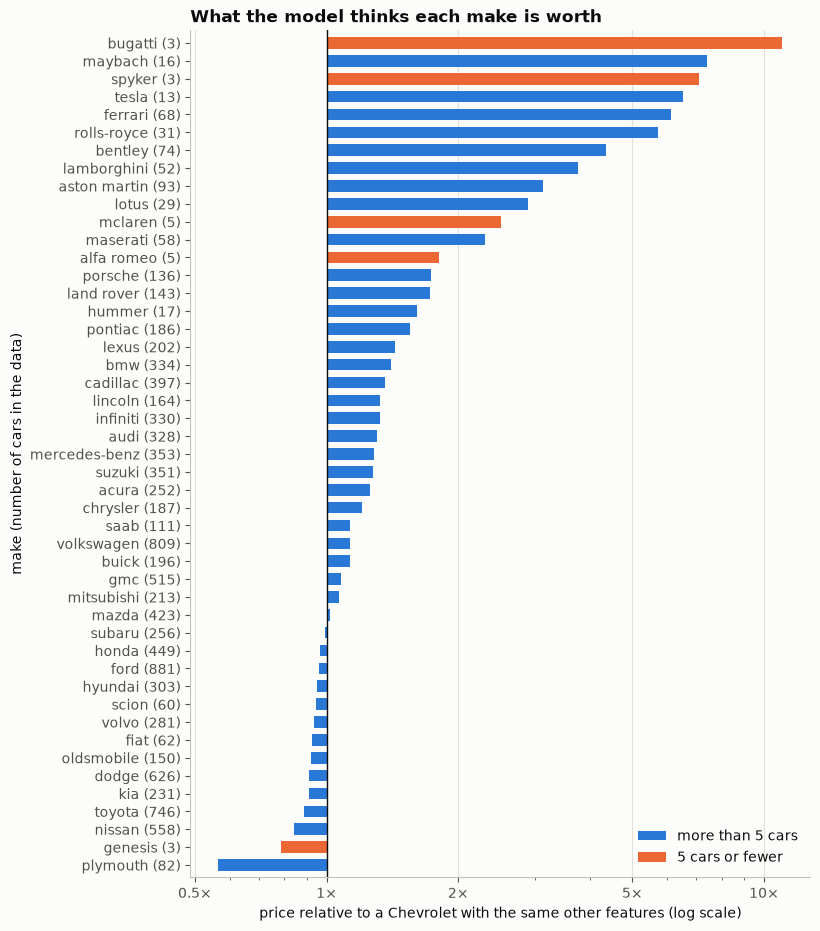

In [ ]:
counts = df_corrected.make.value_counts()
makes = [make for make, _ in ranked][::-1]                      # barh draws from the bottom up
multiplier = np.exp([make_weights[make] for make in makes])     # log-price weight -> "times the price"
rare = np.array([counts[make] <= 5 for make in makes])

fig, ax = plt.subplots(figsize=(8, 11))
positions = np.arange(len(makes))
for mask, color, label in [(~rare, BLUE, 'more than 5 cars'), (rare, ORANGE, '5 cars or fewer')]:
    # Bars grow from 1 (the same price as a Chevrolet) to the make's multiplier, left or right.
    ax.barh(positions[mask], multiplier[mask] - 1, left=1, height=0.65, color=color, label=label)
ax.set_xscale('log')
ax.axvline(1, color=INK, linewidth=1)
ax.set_yticks(positions, [f'{make} ({counts[make]})' for make in makes])
ax.set_ylim(-0.7, len(makes) - 0.3)
ax.grid(axis='y', visible=False)
ax.set_xticks([0.5, 1, 2, 5, 10])
ax.xaxis.set_major_formatter(lambda value, _: f'{value:g}×')
ax.set_xlabel('price relative to a Chevrolet with the same other features (log scale)')
ax.set_ylabel('make (number of cars in the data)')
ax.set_title('What the model thinks each make is worth')
ax.legend(loc='lower right')
plt.show()

**Reading the chart.** There is one bar per make, sorted from the most to the least expensive. Each bar starts at 1× (the black line: the same price as a comparable Chevrolet) and ends at the price the model predicts for that make, relative to a Chevrolet with the same horsepower, fuel economy, age and doors. The horizontal axis is logarithmic, so 2× and 0.5× are the same distance from the line. The number in brackets is how many cars of that make are in the data.

The ranking makes sense: exotic brands at the top, budget brands at the bottom. But look at the orange bars, the makes with 5 cars or fewer. They include the very top of the chart (Bugatti, about 11×, fitted on 3 cars) and one of the bottom three (Genesis, also fitted on 3). A weight fitted on 3 cars mostly repeats those 3 cars' prices. Section 11 deals with that.

## 10. Does the make actually help?

One split proves nothing -- that was the lesson of section 8. So we repeat the comparison over 40 seeds.

This time we have to wrap the training in a `try`, and the reason why is the subject of the next section.

In [ ]:
errors_without_make = []
errors_with_make = []
failed_seeds = []

for seed in range(40):
    _, e_without, _ = model_prediction_full(
        df_corrected, new_features=['car_age'] + door_columns, seed=seed)
    errors_without_make.append(e_without)

    try:
        _, e_with, _ = model_prediction_full(
            df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, seed=seed)
    except np.linalg.LinAlgError:
        e_with = np.nan          # this split could not be trained at all
        failed_seeds.append(seed)
    errors_with_make.append(e_with)

errors_without_make = np.array(errors_without_make)
errors_with_make = np.array(errors_with_make)

trained = ~np.isnan(errors_with_make)
improvement = (errors_without_make - errors_with_make)[trained]

print(f"could not be trained at all on {len(failed_seeds)} of 40 seeds: {failed_seeds}")
print()
print(f"on the {trained.sum()} seeds that did train:")
print(f"  average improvement from the make: {improvement.mean():+.4f}")
print(f"  the make helped on {(improvement > 0).sum()} of {trained.sum()} seeds")
print(f"  the improvement ranges from {improvement.min():+.4f} to {improvement.max():+.4f}")

could not be trained at all on 9 of 40 seeds: [3, 8, 10, 20, 22, 25, 27, 31, 35]

on the 31 seeds that did train:
  average improvement from the make: +0.0680
  the make helped on 30 of 31 seeds
  the improvement ranges from -0.0067 to +0.0834


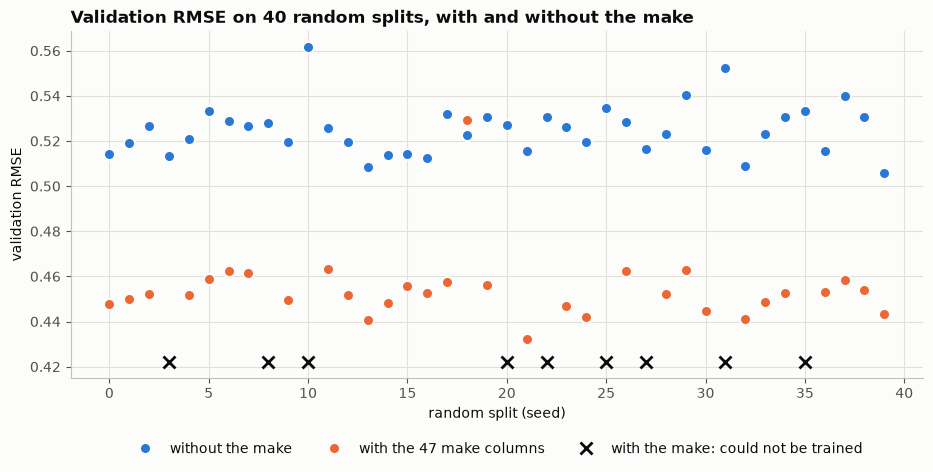

the seed where the make made things worse: [18]


In [ ]:
seeds = np.arange(40)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(seeds, errors_without_make, 'o', color=BLUE, markersize=8, markeredgecolor=BACKGROUND,
        markeredgewidth=1.5, label='without the make')
ax.plot(seeds[trained], errors_with_make[trained], 'o', color=ORANGE, markersize=8, markeredgecolor=BACKGROUND,
        markeredgewidth=1.5, label='with the 47 make columns')
floor = np.nanmin(errors_with_make) - 0.01
ax.plot(failed_seeds, [floor] * len(failed_seeds), 'x', color=INK, markersize=8, markeredgewidth=2,
        label='with the make: could not be trained')
ax.set_title('Validation RMSE on 40 random splits, with and without the make')
ax.set_xlabel('random split (seed)')
ax.set_ylabel('validation RMSE')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=3)
plt.show()

print('the seed where the make made things worse:', seeds[trained][improvement < 0])

**Reading the chart.** The same kind of chart, now for the make. The blue dots are the model without the make and the orange dots the model with the 47 make columns. A black cross marks a split where the model with the make could not be trained at all.

This time the two groups of dots are clearly apart. On 30 of the 31 splits that trained, the orange dot sits far below the blue one, by about 0.07 on average. That gap is several times larger than the jumps from one split to the next, so it isn't luck. The one exception is split 18, where the orange dot is slightly above the blue one. The nine crosses are the real surprise, and they are what the rest of this section is about.

Two results here, and the second is the bigger deal.

**The make helps, clearly.** An average improvement of +0.068, on 30 of the 31 seeds that trained. Compare that with the doors in section 8: +0.00001, on 31 of 40. Changing the split moves the RMSE by about 0.01, so the make is worth several times the noise, while the doors were worth nothing at all.

**But on 9 of the 40 seeds the model could not be trained.** `np.linalg.inv` raised `LinAlgError: Singular matrix` -- it refused outright, rather than returning nonsense the way it did in section 6. Let's look at one of those seeds.

In [ ]:
# Seed 20 is one of the failures. Which makes have no cars at all in its training set?
train_20 = dataflow(df_corrected, seed=20)['df_train']
missing = [name[len('make_is_'):] for name in make_columns if train_20[name].sum() == 0]
print('makes with no cars in the training set:', missing)

# There are only 3 genesis cars in the whole dataset, and this split put all 3 outside the training set.
print()
print(df_corrected[df_corrected.make == 'genesis'][['make', 'model', 'year', 'msrp']])

X_train = input_matrix(train_20, base_features=BASE_WITHOUT_POPULARITY, new_features=features)
XTX = X_train.T @ X_train
column = 1 + len(BASE_WITHOUT_POPULARITY) + features.index('make_is_genesis')

print()
print(f"the make_is_genesis column of X_train is all zeros: {(X_train[:, column] == 0).all()}")
print(f"so row {column} of XTX is all zeros:                 {(XTX[column] == 0).all()}")
print(f"determinant of XTX:                                 {np.linalg.det(XTX)}")
print(f"rank of XTX: {np.linalg.matrix_rank(XTX)} out of {XTX.shape[0]} columns")

makes with no cars in the training set: ['genesis']

         make model  year   msrp
5202  genesis   g80  2017  41400
5203  genesis   g80  2017  54550
5204  genesis   g80  2017  43900

the make_is_genesis column of X_train is all zeros: True
so row 21 of XTX is all zeros:                 True
determinant of XTX:                                 0.0
rank of XTX: 53 out of 54 columns


### A third disguise of the same rule

There are only 3 Genesis cars in the whole dataset, and seed 20 happened to put all 3 of them outside the training set. So the training set contains no Genesis at all, and the `make_is_genesis` column is **all zeros**.

An all-zero column is an exact recipe too -- the trivial one, zero times anything else. This time the consequence is not subtle: if a column of $X$ is all zeros, then the matching row and column of $X^T X$ are all zeros, the determinant is exactly 0 (not $10^{-20}$, but 0), and NumPy raises an error instead of quietly returning garbage.

So we have now met the same rule three times:

| section | the redundant column | how it broke |
|---|---|---|
| 6 | `has_2 + has_3 + has_4` equals the bias column | silent garbage (RMSE 16.5) |
| 9 | `popularity` is a recipe of the make columns | silent garbage (RMSE 95.2) |
| 10 | `make_is_genesis` is all zeros in the training set | `LinAlgError` |

Dropping a column fixed the first two. It cannot fix the third: *which* make goes missing depends on the split, so we would have to drop a different column for every seed -- and we would still have nothing at all to say about a Genesis.

We need something that makes $X^T X$ invertible whatever the split looks like. That is regularization.

## 11. Ridge regression

The idea is almost embarrassingly simple. Before inverting, add a small number $r$ to every entry on the diagonal of $X^T X$:

$$w = (X^T X + rI)^{-1} X^T y$$

Why does that help? A matrix has no inverse when some direction in it is completely "flat", and the all-zero Genesis row is as flat as a direction can get. Adding $r$ along the diagonal lifts every direction by $r$, so none of them is completely flat any more and the inverse always exists.

It also does a second thing, which is the reason ridge regression is used even when the matrix is perfectly healthy. Adding $r$ to the diagonal is the same as telling the model: *make the errors small, but also keep the weights small*. A larger $r$ means "I trust these weights less". That matters here, because some of our weights are fitted on almost no data. Bugatti has 3 cars, and its weight claims a Bugatti is 999% more expensive than a Chevrolet. That number is memorising 3 cars, not learning about Bugattis.

One detail: we do **not** add $r$ to the first diagonal entry, the one belonging to the bias. The bias is the typical log price of a reference car, and shrinking it toward zero would drag every prediction toward a price of \$0 for no good reason. Only the feature weights get shrunk.

In [ ]:
def ridge_regression_training(X: np.ndarray, y: np.ndarray, r: float = 0.0):
    XTX = X.T.dot(X)

    # The identity matrix, except for the bias entry, which stays 0 so that the bias is not shrunk.
    I = np.eye(XTX.shape[0])
    I[0, 0] = 0

    XTX_inv = np.linalg.inv(XTX + r * I)
    w = XTX_inv.dot(X.T).dot(y)

    assert w.shape[0] == X.shape[1]

    return w


# The same model_prediction_full as in section 5, with r added. With r = 0 it is exactly the old
# function (adding 0 to the diagonal changes nothing), so every result above still reproduces.
def model_prediction_full(df: pd.DataFrame,
                          base_features=('engine_hp', 'highway_mpg', 'city_mpg', 'popularity'),
                          new_features=(), r: float = 0.0, seed: int = 0):
    dataset = dataflow(df, seed=seed)
    df_train = dataset['df_train']
    df_valid = dataset['df_valid']

    X_train = input_matrix(df_train, base_features, new_features=new_features)
    X_valid = input_matrix(df_valid, base_features, new_features=new_features)
    y_train = df_train.msrp_log.values
    y_valid = df_valid.msrp_log.values

    w = ridge_regression_training(X_train, y_train, r)
    predictions = X_valid @ w
    error = rmse(y_valid, predictions)

    return predictions, error, w

Seed 20 is the split that could not be trained at all. Let's try it again with a few values of $r$.

In [ ]:
for r in [0, 0.0001, 0.001, 0.01, 0.1, 1, 10]:
    try:
        _, error, _ = model_prediction_full(
            df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, r=r, seed=20)
        print(f"  r = {r:<8} rmse = {error:.4f}")
    except np.linalg.LinAlgError as e:
        print(f"  r = {r:<8} LinAlgError: {e}")

  r = 0        LinAlgError: Singular matrix
  r = 0.0001   rmse = 0.4543
  r = 0.001    rmse = 0.4543
  r = 0.01     rmse = 0.4543
  r = 0.1      rmse = 0.4543
  r = 1        rmse = 0.4549
  r = 10       rmse = 0.4645


Even $r = 0.0001$ is enough to make the matrix invertible. But which $r$ should we actually use? That is a choice, and we make it the same way we made every other choice in this notebook: by measuring on the **validation** set.

In [ ]:
print('r          validation rmse')
for r in [0, 0.0001, 0.001, 0.01, 0.1, 0.3, 1, 3, 10, 100]:
    _, error, _ = model_prediction_full(
        df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, r=r, seed=0)
    print(f"{r:<10} {error:.6f}")

r          validation rmse
0          0.447792
0.0001     0.447792
0.001      0.447792
0.01       0.447787
0.1        0.447766
0.3        0.447806
1          0.448314
3          0.450286
10         0.456663
100        0.484079


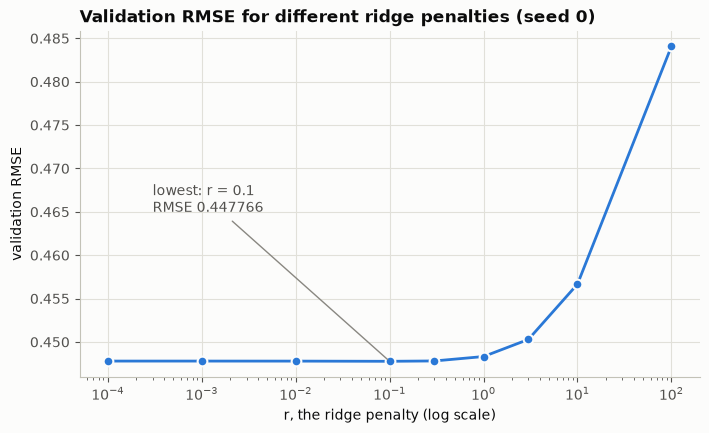

In [ ]:
r_values = [0.0001, 0.001, 0.01, 0.1, 0.3, 1, 3, 10, 100]
errors_r = [model_prediction_full(df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, r=r)[1]
            for r in r_values]
best = int(np.argmin(errors_r))

fig, ax = plt.subplots()
ax.plot(r_values, errors_r, color=BLUE)
ax.plot(r_values, errors_r, 'o', color=BLUE, markersize=7, markeredgecolor=BACKGROUND, markeredgewidth=1.5)
ax.annotate(f'lowest: r = {r_values[best]}\nRMSE {errors_r[best]:.6f}', xy=(r_values[best], errors_r[best]),
            xytext=(0.0003, 0.465), arrowprops=dict(arrowstyle='-', color=GREY), color='#52514e')
ax.set_xscale('log')
ax.set_title('Validation RMSE for different ridge penalties (seed 0)')
ax.set_xlabel('r, the ridge penalty (log scale)')
ax.set_ylabel('validation RMSE')
plt.show()

**Reading the chart.** The horizontal axis is the ridge penalty `r` on a log scale (each tick is 10 times the one before), and the vertical axis is the validation RMSE. The line is flat from r = 0.0001 to about r = 1. The lowest point, r = 0.1, beats its neighbours only in the fifth decimal place, which is invisible at this scale. Beyond r = 1 the RMSE climbs: the penalty pulls the weights toward 0 so hard that the model starts to forget real differences between cars. (r = 0 can't be drawn, because a log scale has no 0; it gives the same RMSE as r = 0.0001.)

Notice what this table does *not* say. On seed 0 the best $r$ is 0.1, and it improves the RMSE from 0.447792 to 0.447766 -- a change in the fifth decimal place. Ridge regression is not making this model more accurate.

What it buys us is that the model can be trained at all. Let's redo the 40-seed comparison with $r = 0.01$.

In [ ]:
errors_ridge = []

for seed in range(40):
    _, error, _ = model_prediction_full(
        df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, r=0.01, seed=seed)
    errors_ridge.append(error)

errors_ridge = np.array(errors_ridge)

print(f"plain linear regression: trained on {trained.sum()} of 40 seeds")
print(f"ridge (r = 0.01):        trained on {len(errors_ridge)} of 40 seeds")
print()
print(f"on the {trained.sum()} seeds where both worked:")
print(f"  plain: {errors_with_make[trained].mean():.4f}")
print(f"  ridge: {errors_ridge[trained].mean():.4f}")
print()
print(f"on the {(~trained).sum()} seeds where plain regression refused, ridge gets: {errors_ridge[~trained].mean():.4f}")

plain linear regression: trained on 31 of 40 seeds
ridge (r = 0.01):        trained on 40 of 40 seeds

on the 31 seeds where both worked:
  plain: 0.4543
  ridge: 0.4543

on the 9 seeds where plain regression refused, ridge gets: 0.4903


On the 31 seeds where both work, ridge and plain regression give the same average RMSE, 0.4543 -- ridge costs us nothing. On the 9 seeds where plain regression simply refuses, ridge trains and gets 0.4903. (Those splits are genuinely harder ones, which is part of why plain regression choked on them.)

That is the honest summary of ridge regression here: **not more accurate, but always trainable**. It is free insurance.

The other half of the story is what $r$ does to the weights themselves. Watch the Bugatti weight, which is fitted on 3 cars.

In [ ]:
print(f"{'r':<8} {'bugatti':>10} {'spyker':>10} {'toyota':>10}   sum of |weights|")
for r in [0, 0.01, 1, 10, 100]:
    _, _, w_r = model_prediction_full(
        df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, r=r, seed=0)
    weight_of = lambda make: np.expm1(w_r[1 + feature_names.index(f'make_is_{make}')])
    print(f"{r:<8} {weight_of('bugatti'):>+10.0%} {weight_of('spyker'):>+10.0%} "
          f"{weight_of('toyota'):>+10.1%}   {np.abs(w_r[1:]).sum():.2f}")

r           bugatti     spyker     toyota   sum of |weights|
0             +999%      +610%     -11.4%   26.46
0.01          +985%      +603%     -11.5%   26.40
1             +356%      +259%     -13.6%   22.55
10             +36%       +34%     -19.9%   13.52
100             +2%        +3%     -18.4%   4.88


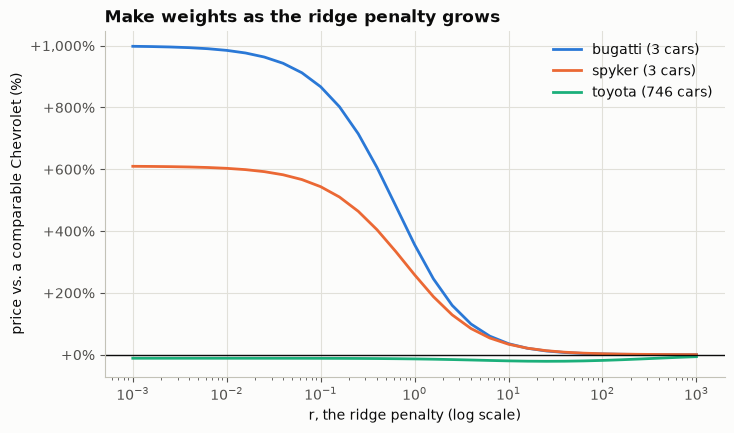

In [ ]:
r_grid = np.logspace(-3, 3, 31)
shown = {'bugatti': BLUE, 'spyker': ORANGE, 'toyota': GREEN}
curves = {make: [] for make in shown}
for r in r_grid:
    _, _, w_r = model_prediction_full(
        df_corrected, base_features=BASE_WITHOUT_POPULARITY, new_features=features, r=r, seed=0)
    for make in shown:
        curves[make].append(np.expm1(w_r[1 + feature_names.index(f'make_is_{make}')]) * 100)

fig, ax = plt.subplots()
for make, color in shown.items():
    ax.plot(r_grid, curves[make], color=color, label=f'{make} ({(df_corrected.make == make).sum()} cars)')
ax.axhline(0, color=INK, linewidth=1)
ax.set_xscale('log')
ax.set_title('Make weights as the ridge penalty grows')
ax.set_xlabel('r, the ridge penalty (log scale)')
ax.set_ylabel('price vs. a comparable Chevrolet (%)')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:+,.0f}%')
ax.legend()
plt.show()

**Reading the chart.** The horizontal axis is again the ridge penalty `r` (log scale). The vertical axis is how much more or less expensive than a comparable Chevrolet the model thinks each make is. The Bugatti and Spyker weights, fitted on 3 cars each, start at +999% and +610% and collapse toward 0 once `r` passes about 0.1. The Toyota weight, fitted on 746 cars, barely moves on this scale. Ridge shrinks most the weights that the data supports least, and that's exactly its purpose.

As $r$ grows, the weights are pulled toward zero: the Bugatti weight falls from +999% to +36% to +2%, and the total size of all the weights falls from 26.5 to 4.9. The contrast with Toyota is the point: its weight is fitted on 746 cars and stays in the same range the whole way down, while Bugatti's, fitted on 3, collapses to nothing.

That is the trade-off $r$ controls. Too small, and rare makes get wild weights fitted on 3 cars. Too large, and every make is squeezed toward the average and the model forgets the real differences between brands. We pick $r$ on the validation set, which is what the table above did.

One caveat worth stating, because it is a real limitation of what we just did: a single $r$ penalises every weight by the same amount, but our columns are on wildly different scales (`engine_hp` runs into the hundreds, the make columns are 0 or 1). So $r$ leans much harder on the make columns than on `engine_hp`. The usual remedy is to rescale every column to a comparable range before fitting. We leave that for the "what to try next" list below.

## 12. The final model: one look at the test set

Everything so far was decided on the validation set: which features to use, which column to drop as the reference, and which $r$. The test set has not been touched since section 2.

Now we train one last model -- on the training **and** validation cars together, since there is no tuning left to do -- and evaluate it on the test set exactly once. Whatever number comes out is the number we report.

In [ ]:
dataset = dataflow(df_corrected)
df_train_valid = dataset['df_train_valid']
df_test = dataset['df_test']

X_train_valid = input_matrix(df_train_valid, BASE_WITHOUT_POPULARITY, new_features=features)
X_test = input_matrix(df_test, BASE_WITHOUT_POPULARITY, new_features=features)

y_train_valid = df_train_valid.msrp_log.values
y_test = df_test.msrp_log.values

w_final = ridge_regression_training(X_train_valid, y_train_valid, r=0.1)
test_predictions = X_test @ w_final

print(f"trained on {len(df_train_valid)} cars, tested on {len(df_test)} cars")
print(f"test rmse: {rmse(y_test, test_predictions):.4f}")

trained on 9525 cars, tested on 2383 cars
test rmse: 0.4528


0.4528 on the test set, against 0.4478 on the validation set. The two are close, which is exactly what we hoped for: it means we did not overfit our choices to the validation cars.

An RMSE of 0.45 in log-price units is hard to feel, so let's look at real dollars.

In [ ]:
predicted_prices = np.expm1(test_predictions)
real_prices = df_test.msrp.values
off_by = (predicted_prices - real_prices) / real_prices

print(f"median error: {np.median(np.abs(off_by)):.1%} of the real price")
print()

comparison = pd.DataFrame({
    'make': df_test.make.values[:10],
    'model': df_test.model.values[:10],
    'real price': [f'${p:,.0f}' for p in real_prices[:10]],
    'predicted price': [f'${p:,.0f}' for p in predicted_prices[:10]],
    'off by': [f'{d:+.0%}' for d in off_by[:10]],
})
comparison

median error: 25.2% of the real price



,make,model,real price,predicted price,off by
0,pontiac,torrent,"$24,820","$24,754",-0%
1,gmc,savana cargo,"$34,800","$41,212",+18%
2,mazda,b-series truck,"$16,060","$14,408",-10%
3,volkswagen,golf gti,"$26,485","$33,622",+27%
4,subaru,forester,"$30,095","$26,224",-13%
5,nissan,pathfinder,"$41,610","$33,301",-20%
6,toyota,tacoma,"$29,280","$29,768",+2%
7,kia,soul ev,"$35,700","$15,308",-57%
8,mazda,rx-8,"$27,860","$19,670",-29%
9,mercedes-benz,s-class,"$160,900","$110,022",-32%


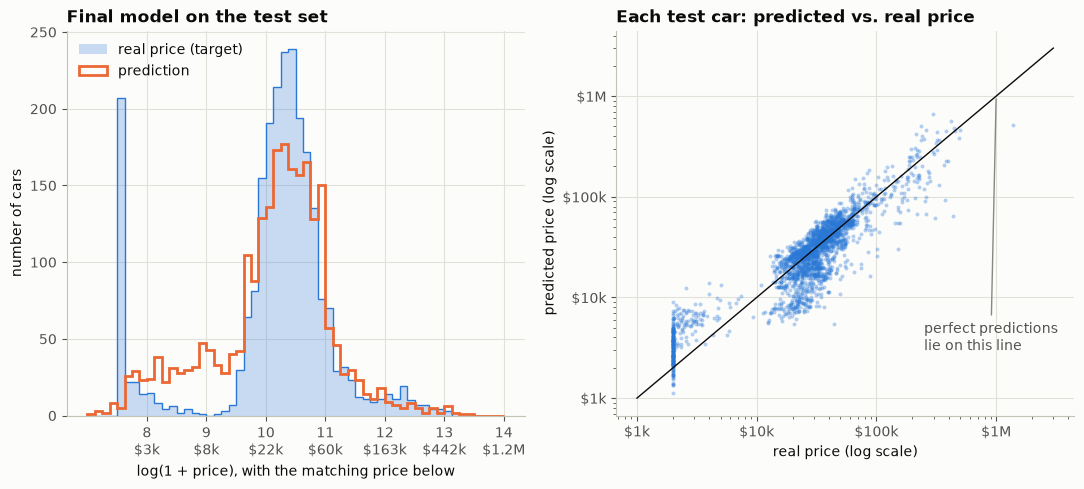

test cars priced at exactly $2,000: 203, predicted between $1,133 and $9,109
test cars above $200,000: 59, median predicted/real price: 0.85


In [ ]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))
plot_predictions(left, y_test, test_predictions, 'Final model on the test set')

right.scatter(real_prices, predicted_prices, s=8, color=BLUE, alpha=0.35, linewidths=0)
right.plot([1e3, 3e6], [1e3, 3e6], color=INK, linewidth=1)
right.set_xscale('log')
right.set_yscale('log')
right.set_title('Each test car: predicted vs. real price')
right.set_xlabel('real price (log scale)')
right.set_ylabel('predicted price (log scale)')
for axis in (right.xaxis, right.yaxis):
    axis.set_major_formatter(lambda value, _: f'${value / 1e6:g}M' if value >= 1e6 else f'${value / 1e3:g}k')
right.annotate('perfect predictions\nlie on this line', xy=(1e6, 1e6), xytext=(2.5e5, 3e3),
               arrowprops=dict(arrowstyle='-', color=GREY), color='#52514e')
plt.show()

placeholder = real_prices == 2000
print(f'test cars priced at exactly $2,000: {placeholder.sum()}, '
      f'predicted between ${predicted_prices[placeholder].min():,.0f} and ${predicted_prices[placeholder].max():,.0f}')
expensive = real_prices > 200_000
print(f'test cars above $200,000: {expensive.sum()}, median predicted/real price: {np.median(predicted_prices[expensive] / real_prices[expensive]):.2f}')

**Reading the chart.** The left panel is the same kind of chart as in section 3, now for the final model on the test set. Compared with the very first model, the orange outline follows the blue shape closely almost everywhere, except at the \$2,000 spike. On the right, each dot is one test car, with its real price on the horizontal axis and its predicted price on the vertical axis, both on log scales (each gridline is 10 times the one before). Dots on the black line are perfect predictions: a dot above the line was priced too high by the model, a dot below too low.

Two patterns stand out. The vertical stripe at \$2,000 is the 203 test cars with the placeholder price, predicted at anything from \$1,133 to \$9,109: the model has no way to know the price is fake. And at the top end, the 59 test cars above \$200,000 lean below the line. Their median prediction is 0.85 times the real price, so the most expensive cars tend to be underpriced.

The typical prediction is about a quarter away from the real price. That is a long way from a tool you would trust with your own money, but it is a reasonable result for a model built from four numbers, an age and a brand name, with no scikit-learn in sight.

## 13. Results and what to try next

Every model in this notebook, each scored on the validation set (seed 0):

In [ ]:
# (name, data, base features, extra features, r, what it shows)
experiments = [
    ('base features', 'df', BASE_FEATURES, [], 0,
     'starting point'),
    ('+ car_age', 'df', BASE_FEATURES, ['car_age'], 0,
     'the age matters a lot'),
    ('+ car_age + 3 door columns', 'df', BASE_FEATURES,
     ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors'], 0,
     'barely changes; only works thanks to 6 cars'),
    ('+ car_age + 3 door columns', 'df_corrected', BASE_FEATURES,
     ['car_age', 'has_2_doors', 'has_3_doors', 'has_4_doors'], 0,
     'dummy variable trap: broken'),
    ('+ car_age', 'df_corrected', BASE_FEATURES, ['car_age'], 0,
     'new baseline after removing the 6 cars'),
    ('+ car_age + 2 door columns', 'df_corrected', BASE_FEATURES,
     ['car_age'] + door_columns, 0,
     'fixed, but the doors add ~nothing'),
    ('+ 48 make columns', 'df_corrected', BASE_FEATURES,
     ['car_age'] + door_columns + all_make_columns, 0,
     'dummy variable trap again'),
    ('+ 47 make columns', 'df_corrected', BASE_FEATURES, features, 0,
     'still broken: popularity is a recipe'),
    ('+ 47 make columns, no popularity', 'df_corrected', BASE_WITHOUT_POPULARITY, features, 0,
     'the make is a real improvement'),
    ('... and ridge, r = 0.1', 'df_corrected', BASE_WITHOUT_POPULARITY, features, 0.1,
     'same accuracy, but always trainable'),
]
datasets = {'df': df, 'df_corrected': df_corrected}

rows = []
for name, data, base, extra, r, note in experiments:
    _, error, _ = model_prediction_full(datasets[data], base_features=base, new_features=extra, r=r)
    rows.append({'model': name, 'data': data, 'validation rmse': round(error, 4), 'what it shows': note})

results = pd.DataFrame(rows)
results.index = results.index + 1  # number the models from 1
results

,model,data,validation rmse,what it shows
1,base features,df,0.7734,starting point
2,+ car_age,df,0.5301,the age matters a lot
3,+ car_age + 3 door columns,df,0.5279,barely changes; only works thanks to 6 cars
4,+ car_age + 3 door columns,df_corrected,16.5354,dummy variable trap: broken
5,+ car_age,df_corrected,0.5146,new baseline after removing the 6 cars
6,+ car_age + 2 door columns,df_corrected,0.5143,"fixed, but the doors add ~nothing"
7,+ 48 make columns,df_corrected,111.2961,dummy variable trap again
8,+ 47 make columns,df_corrected,95.2455,still broken: popularity is a recipe
9,"+ 47 make columns, no popularity",df_corrected,0.4478,the make is a real improvement
10,"... and ridge, r = 0.1",df_corrected,0.4478,"same accuracy, but always trainable"


### Summary

- Adding the age of the car brought the validation RMSE from 0.773 to 0.530.
- The number of doors, one-hot encoded, makes almost no difference. Measuring over 40 seeds is the only way we could tell.
- The make of the car does help: 0.5143 to 0.4478, confirmed on 30 of 31 seeds.
- The final model scores **0.4528 on the test set** -- a median error of about 25% of a car's real price.

The thread running through the whole notebook turned out to be a single rule about the input matrix:

> **No column may be an exact recipe of the other columns.**

We broke it three times, in three different disguises -- all three door columns plus the bias, `popularity` alongside the make columns, and a make with no cars in the training split. The first two returned confident nonsense; only the third one raised an error. That is the uncomfortable part: a linear regression that is quietly broken looks exactly like one that works, until you check the condition number or the RMSE.

### What to try next

- **Rescale the columns before ridge.** A single $r$ currently penalises the make columns far more than `engine_hp`, simply because of their different scales.
- **More categorical features**: `engine_cylinders`, `transmission_type`, `vehicle_style`, `driven_wheels`, each with k - 1 columns. Watch out: all 3 sixteen-cylinder cars in this dataset are Bugattis, so a `cyl_16` column would be an exact copy of `make_is_bugatti` -- the same rule again, a fourth time.
- **Fix the remaining `fillna(0)` damage.** Section 6 caught the 6 doorless cars, but the same blanket fill also filed 20 Mazda RX-7s and RX-8s under "0 cylinders", which in this dataset means electric. They are rotary engines, not EVs.
- **Drop the placeholder prices.** 1,036 cars have an MSRP of exactly \$2,000, all of them built between 1990 and 2000. That is not a price, it is a placeholder, and it distorts anything the model learns about old cars.
- **Cross-validation** instead of a single validation split, so that model choices do not depend on one lucky seed.

## 14. Just tell me what my car is worth

If you skipped the tutorial and only want a number: choose **Restart & Run All** from the Kernel menu, scroll
back down here, and edit the very last cell of the notebook with your car's details.

**Read this first, because it changes what the answer means.**

`msrp` is the *Manufacturer's Suggested Retail Price* -- the sticker price of the car when it was **new**.
So if you enter a 2005 Honda, the model predicts roughly what that Honda cost in a showroom in 2005. It is
**not** an estimate of what a used car is worth today. Nothing in this dataset knows about mileage,
condition, service history or what the second-hand market has done since.

A few more honest limits:

- The typical prediction is off by about **25%** of the real price (section 12). Treat the answer as a
  ballpark, not a valuation.
- The model knows exactly **six** things about a car: make, year, horsepower, highway mpg, city mpg and
  number of doors. It has never heard of trim levels, options or body style.
- The data covers **1990 to 2017** and cars sold in the US. Enter 2024 and you are asking the model to
  extrapolate seven years past anything it has seen.
- Rare makes are weakly supported. There are only 3 Bugattis, 3 Spykers and 3 Genesis in the whole dataset,
  so their weights rest on almost nothing (which is exactly what section 11 was about).

In [ ]:
# Predict the new-car price of a single car, in dollars, using w_final from section 12.
def predict_price(make, year, engine_hp, highway_mpg, city_mpg, number_of_doors=4):
    make = str(make).strip().lower()
    if make not in all_makes:
        raise ValueError(f"'{make}' is not one of the 48 makes in this dataset. "
                         f"Run print(all_makes) to see the full list.")
    if number_of_doors not in (2, 3, 4):
        raise ValueError(f"number_of_doors must be 2, 3 or 4, not {number_of_doors}.")

    # Build a one-row table holding exactly the columns the model was trained on, then hand it to the
    # same input_matrix we used for training. Reusing it means the column order cannot drift out of
    # step with w_final, which is the kind of bug that produces a confident, completely wrong number.
    row = {
        'engine_hp': engine_hp,
        'highway_mpg': highway_mpg,
        'city_mpg': city_mpg,
        'car_age': current_year - year,
        'has_2_doors': int(number_of_doors == 2),
        'has_3_doors': int(number_of_doors == 3),
    }
    for column in make_columns:
        row[column] = int(column == f'make_is_{make}')

    x = input_matrix(pd.DataFrame([row]), BASE_WITHOUT_POPULARITY, new_features=features)
    return float(np.expm1(x @ w_final)[0])

Before trusting it with your own car, here is the model against eight real cars from the test set -- cars it
was never trained on. The good and the bad are both shown, because the bad ones tell you what the 25% really
feels like.

In [ ]:
print(f"{'make':14s} {'model':20s} {'real':>10s} {'predicted':>11s}   off by")
for _, car in df_test.head(8).iterrows():
    guess = predict_price(car.make, car.year, car.engine_hp, car.highway_mpg, car.city_mpg,
                          int(car.number_of_doors))
    print(f"{car.make:14s} {car.model[:20]:20s} ${car.msrp:>9,.0f} ${guess:>10,.0f}   {(guess / car.msrp - 1):+.0%}")

make           model                      real   predicted   off by
pontiac        torrent              $   24,820 $    24,754   -0%
gmc            savana cargo         $   34,800 $    41,212   +18%
mazda          b-series truck       $   16,060 $    14,408   -10%
volkswagen     golf gti             $   26,485 $    33,622   +27%
subaru         forester             $   30,095 $    26,224   -13%
nissan         pathfinder           $   41,610 $    33,301   -20%
toyota         tacoma               $   29,280 $    29,768   +2%
kia            soul ev              $   35,700 $    15,308   -57%


The Pontiac and the Toyota are close. The Kia Soul EV is 57% too low, because it is electric and the model
has no idea what that means -- it sees a low-horsepower Kia and prices it like one.

### Your turn

Edit the cell below and run it. The `make` must be one of these 48, spelled exactly like this (capitals and
extra spaces are fine, the function tidies them up):

`acura`, `alfa romeo`, `aston martin`, `audi`, `bentley`, `bmw`, `bugatti`, `buick`, `cadillac`,
`chevrolet`, `chrysler`, `dodge`, `ferrari`, `fiat`, `ford`, `genesis`, `gmc`, `honda`, `hummer`,
`hyundai`, `infiniti`, `kia`, `lamborghini`, `land rover`, `lexus`, `lincoln`, `lotus`, `maserati`,
`maybach`, `mazda`, `mclaren`, `mercedes-benz`, `mitsubishi`, `nissan`, `oldsmobile`, `plymouth`,
`pontiac`, `porsche`, `rolls-royce`, `saab`, `scion`, `spyker`, `subaru`, `suzuki`, `tesla`, `toyota`,
`volkswagen`, `volvo`

If your make is not on the list, the model genuinely cannot help -- it has one weight per make and no way to
reason about a brand it has never seen. The rest of the numbers are on your car's spec sheet; `engine_hp` in
the data runs from 55 to 1001, `highway_mpg` from 12 to 354 and `city_mpg` from 7 to 137.

In [ ]:
# ----------------------------------------------------------------------------
#  EDIT THESE SIX LINES, THEN RUN THIS CELL
# ----------------------------------------------------------------------------
my_car = dict(
    make='bmw',             # one of the 48 makes listed above
    year=2012,              # the model year, 1990-2017
    engine_hp=200,          # horsepower
    highway_mpg=33,
    city_mpg=25,
    number_of_doors=4,      # 2, 3 or 4
)
# ----------------------------------------------------------------------------

estimate = predict_price(**my_car)

print(f"a {my_car['year']} {my_car['make']} with {my_car['engine_hp']} hp")
print(f"probably cost about ${estimate:,.0f} when it was new")
print()
print(f"given the model's typical 25% error, read that as roughly "
      f"${estimate * 0.75:,.0f} to ${estimate * 1.25:,.0f}")

a 2012 bmw with 200 hp
probably cost about $30,633 when it was new

given the model's typical 25% error, read that as roughly $22,974 to $38,291
